In [2]:
import sys
sys.path.append('..')
from utils.fonctions import load_parquet_data, normalize_colnames_list
from src.artifacts.data_processing import Nettoyage
from utils.fonctions import load_pickle
import numpy as np

TARGET_COL = 'consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'

def numerize(data, encoding_pipeline, downcast_num_cols=True):

    def downcast_numeric_cols():
        # int32 range = 2**32/2 à gauche et à droite de 0
        for c in data.columns:
            if data[c].dtype == 'int64':
                data[c] = data[c].astype('int32')
            elif data[c].dtype == 'float64':
                data[c] = data[c].astype('float32')
        return data
    
    encoding_pipeline.set_output(transform='pandas')
    data = encoding_pipeline.fit_transform(data)

    if downcast_num_cols:
        return downcast_numeric_cols()
    return data

In [3]:
# import data frame 2022
df = load_parquet_data('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')
pipeline = Nettoyage(df)

pipeline.run(use_entropy_selection = True)
df_clean_v1 = pipeline.df

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..
-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 250 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 55 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 145 colonnes et 375231 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !
Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['emission_ges_auxiliaires_ademe', 'emission_ges_chauffage_ademe', 'conso_5_usages_e_finale_energie_ndeg1_ademe', 'conso_5_usages_e_finale_ademe', 'conso_ecs_depensier_e_finale_ademe', 'cout_ecs_depensier_ademe', 'conso_eclairage_e_primaire_ademe', 'cout_ecs_energie_ndeg2_ademe', 'conso_refroidissement_depensier_e_finale_ademe', 'emission_ges_ecs_energie_ndeg1_ademe', 'conso_chauffage_e_

In [4]:
# make encoding pipeline

categorical_encoder = load_pickle('../ressources/encoders_fitted/categorical_encoders.pkl')
categorical_encoder

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal_encoding',
                                 OrdinalEncoder(mapping=[{'col': 'qualite_isolation_menuiseries_ademe',
                                                          'data_type': dtype('O'),
                                                          'mapping': insuffisante    1
moyenne         2
bonne           3
très bonne      4
<NA>           -1
dtype: int64},
                                                         {'col': 'qualite_isolation_murs_ademe',
                                                          'data_type': dtype('O'),
                                                          'mapping': insuffisante    1
moyenne         2
bonne           3
très bonne      4
<NA>           -1
dt...
                                  'type_energie_principale_ecs_ademe',
                                  'type_energie_ndeg1_ademe',
                                  'type_installation_ecs_ademe',
                                  'type_enedis_with_ban',
                                  'type_installation_chauffage_ndeg1_ademe',
                                  'type_energie_ndeg2_ademe',
                                  'type_installation_ecs_general_ademe',
                                  'methode_application_dpe_ademe',
                                  'configuration_installation_ecs_ademe',
                                  'type_generateur_ecs_ndeg1_ademe'])],
                  verbose_feature_names_out=False)

In [ ]:
# new_pipeline =  # nouveau pipeline avec standard scaler mais avce étape categ encoders

In [5]:
df = numerize(df_clean_v1, categorical_encoder)

# Stat desc

* conso / deperdition t caractéristiques des logements
* distribution des logements en focntion du DPE
* consommation électrique en focntion du DPE


# Modelisation

In [ ]:
# consommation électrique et impact de chaque varibles, natamment l'importance du DPE
# modèle d'arbre
# regression lineaire : ridge lasso
# modèle de boosting

# part de la consommation / de la déperdition d'énergie et importantce du DPE

# 1. modèle d'arbre

In [6]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error


# séparation des données en target Y et features X
x = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# séparation des données en train et test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=25)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((295264, 87), (73817, 87), (295264,), (73817,))

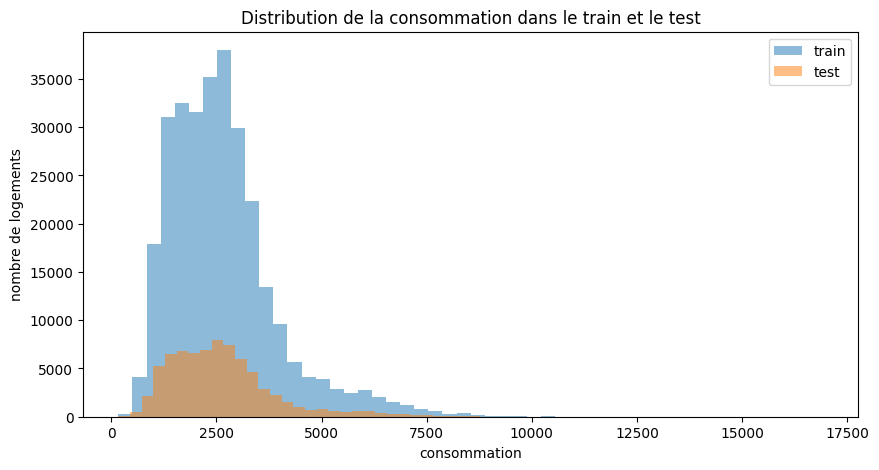

In [10]:
# graphique de la distribution de la consommation dans le train et le test
plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='train')
plt.hist(y_test, bins=50, alpha=0.5, label='test')
plt.xlabel('consommation')
plt.ylabel('nombre de logements')
plt.title('Distribution de la consommation dans le train et le test')
plt.legend()
plt.savefig('../ressources/img/distribution_consommation_train_test_carla.png')
plt.show()
# y_train.describe(), y_test.describe()


In [ ]:
# apprentissage du modèle par validation croisée avec grid search
# DT = DecisionTreeRegressor()

# clf_dt = GridSearchCV(DT, cv=5, param_grid={'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
#                                             'max_depth': [3, 5, 7, 9, 11],
#                                             'splitter':["best", "random"]})


# apprentissage du modèle par validation croisée avec randomized search
# clf_dt = RandomizedSearchCV(DT, cv=5, param_distributions={'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
#                                             'max_depth': [3, 5, 7, 9, 11],
#                                             'splitter':["best",
#     


In [7]:
# apprentissage du modèle 
DT = DecisionTreeRegressor()

mdl_dt = DT.fit(x_train, y_train)
y_pred = mdl_dt.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse, mape, r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(638222.2350948969, 0.16675576060341, 0.6138047335355712, 798.888124267032)

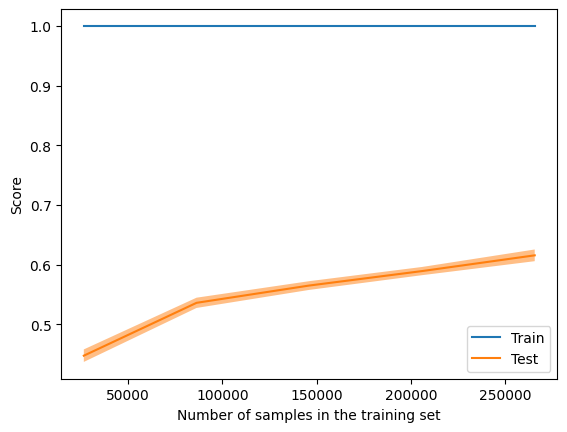

In [12]:
# courbe d'apprentissage 
from sklearn.model_selection import learning_curve, LearningCurveDisplay

train_sizes, train_scores, test_scores = learning_curve(
   DT, x_train, y_train, cv=10, scoring='r2')

display = LearningCurveDisplay(train_sizes=train_sizes,
   train_scores=train_scores, test_scores=test_scores, score_name="Score")

display.plot()
plt.savefig('../ressources/img/learning_curve_DT1_carla.png')
plt.show()


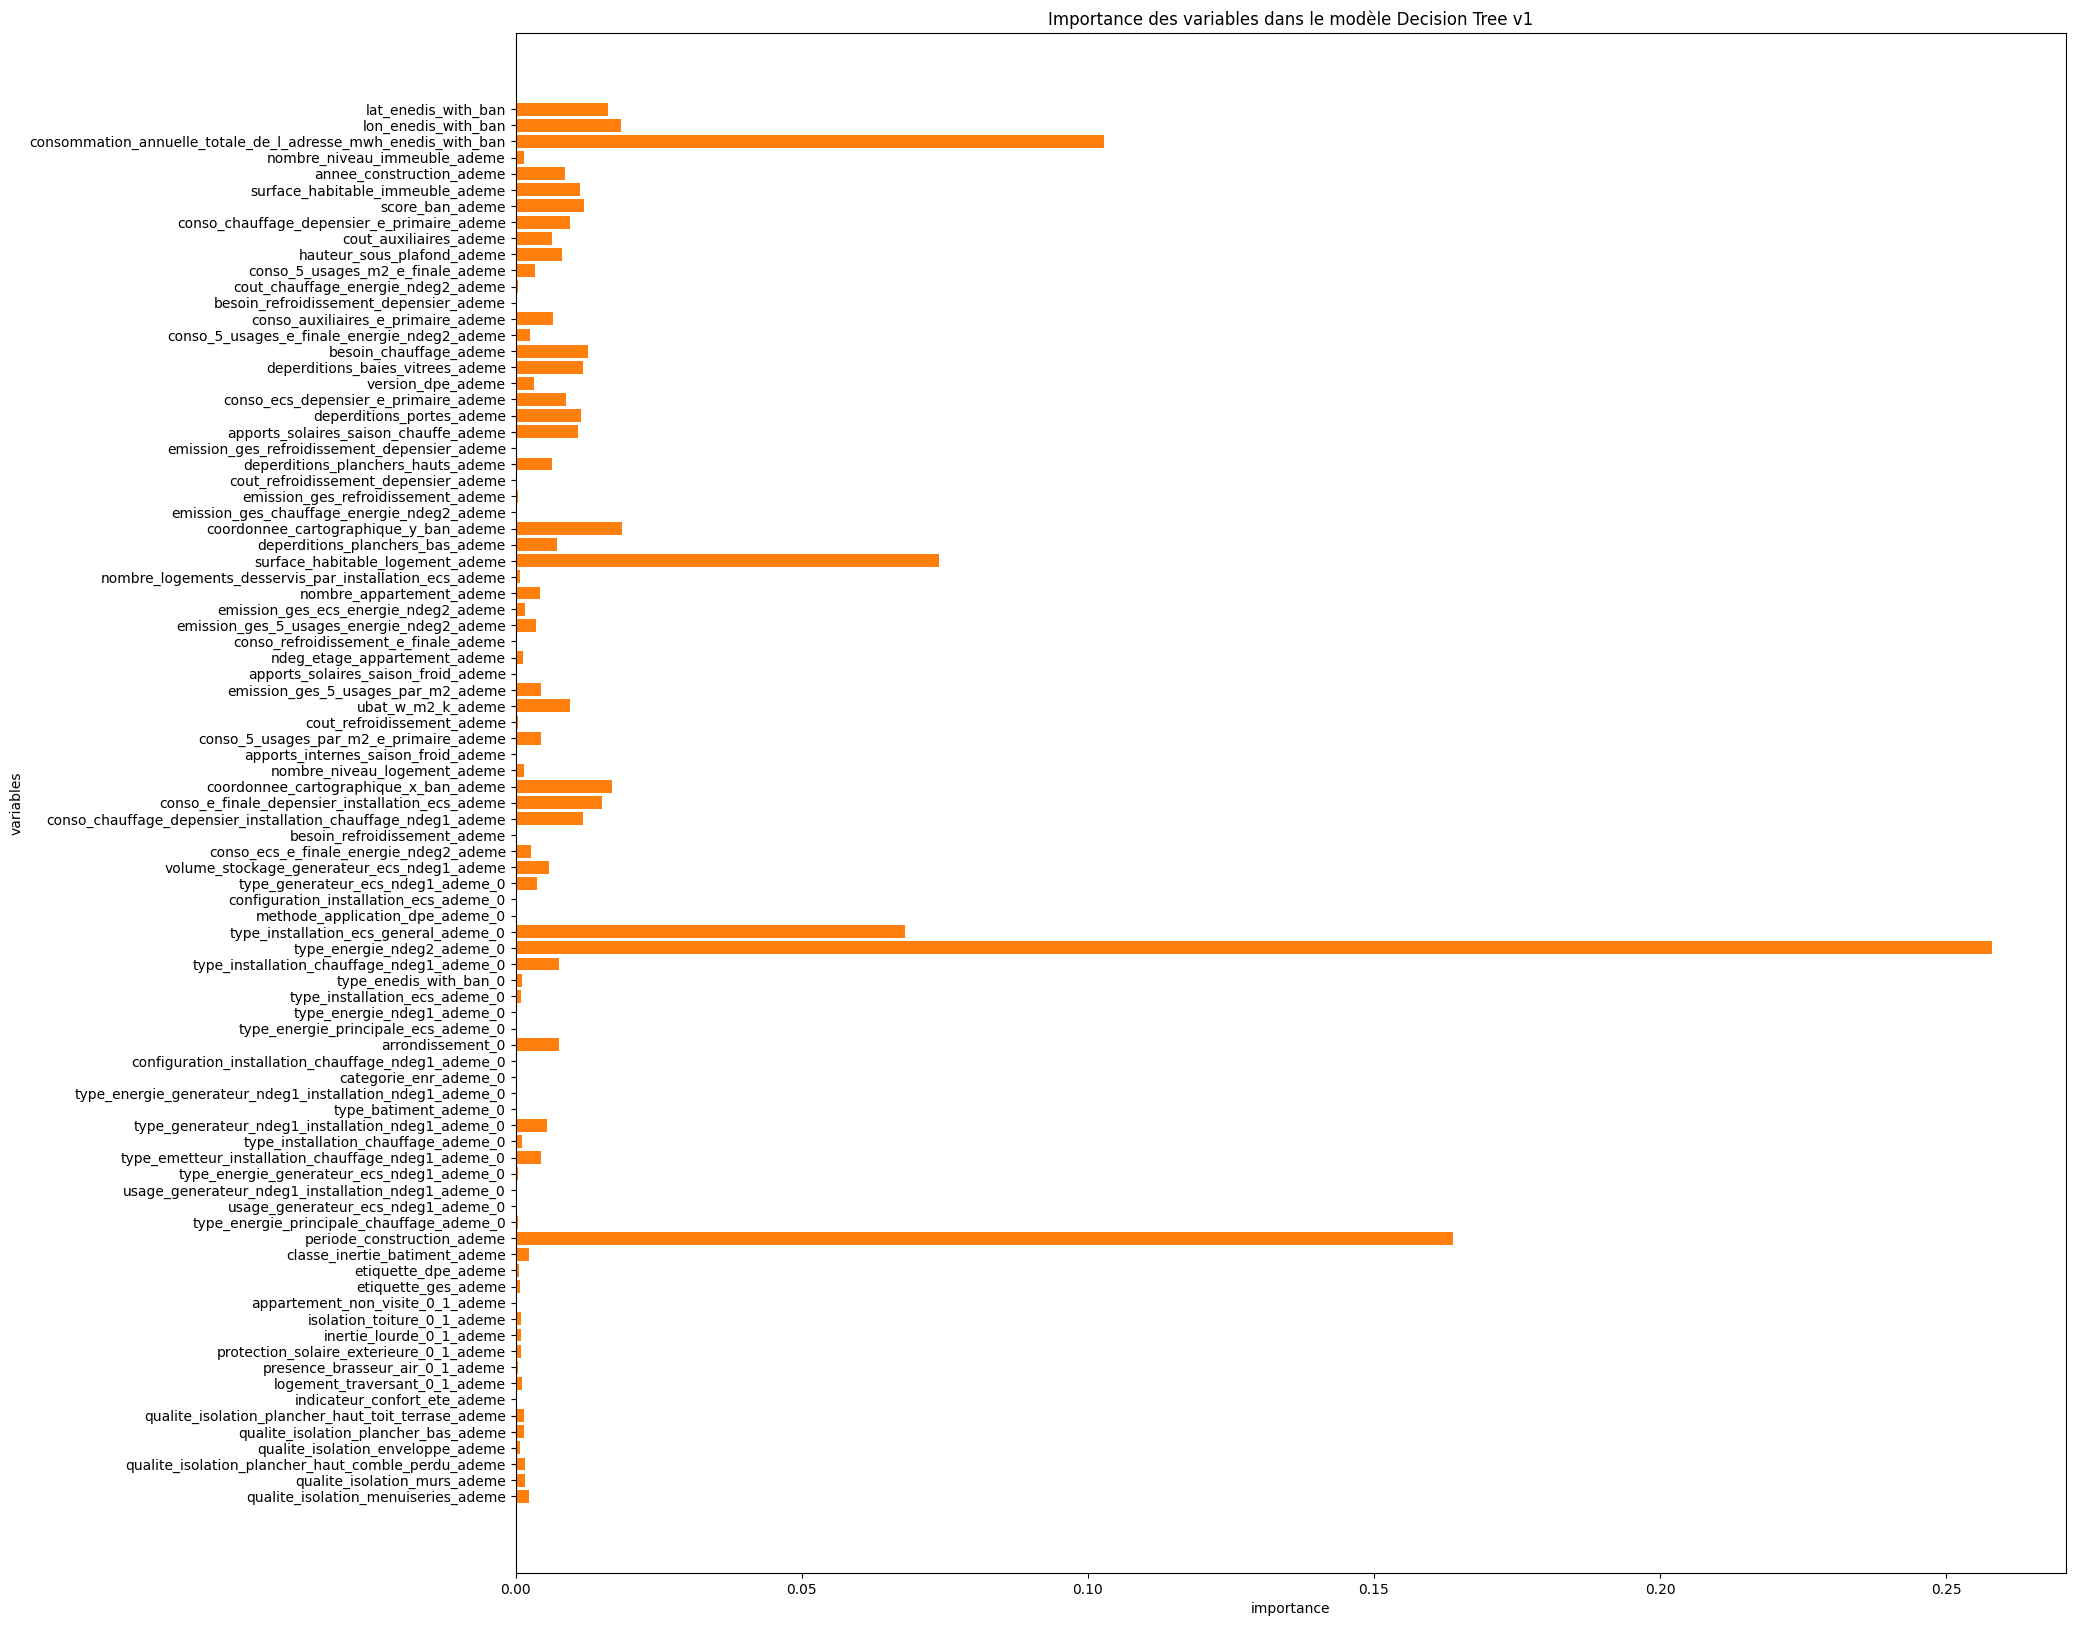

In [17]:
DT.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, DT.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree v1')
plt.savefig('../ressources/img/importance_variables_DT1_carla.png')
plt.show()


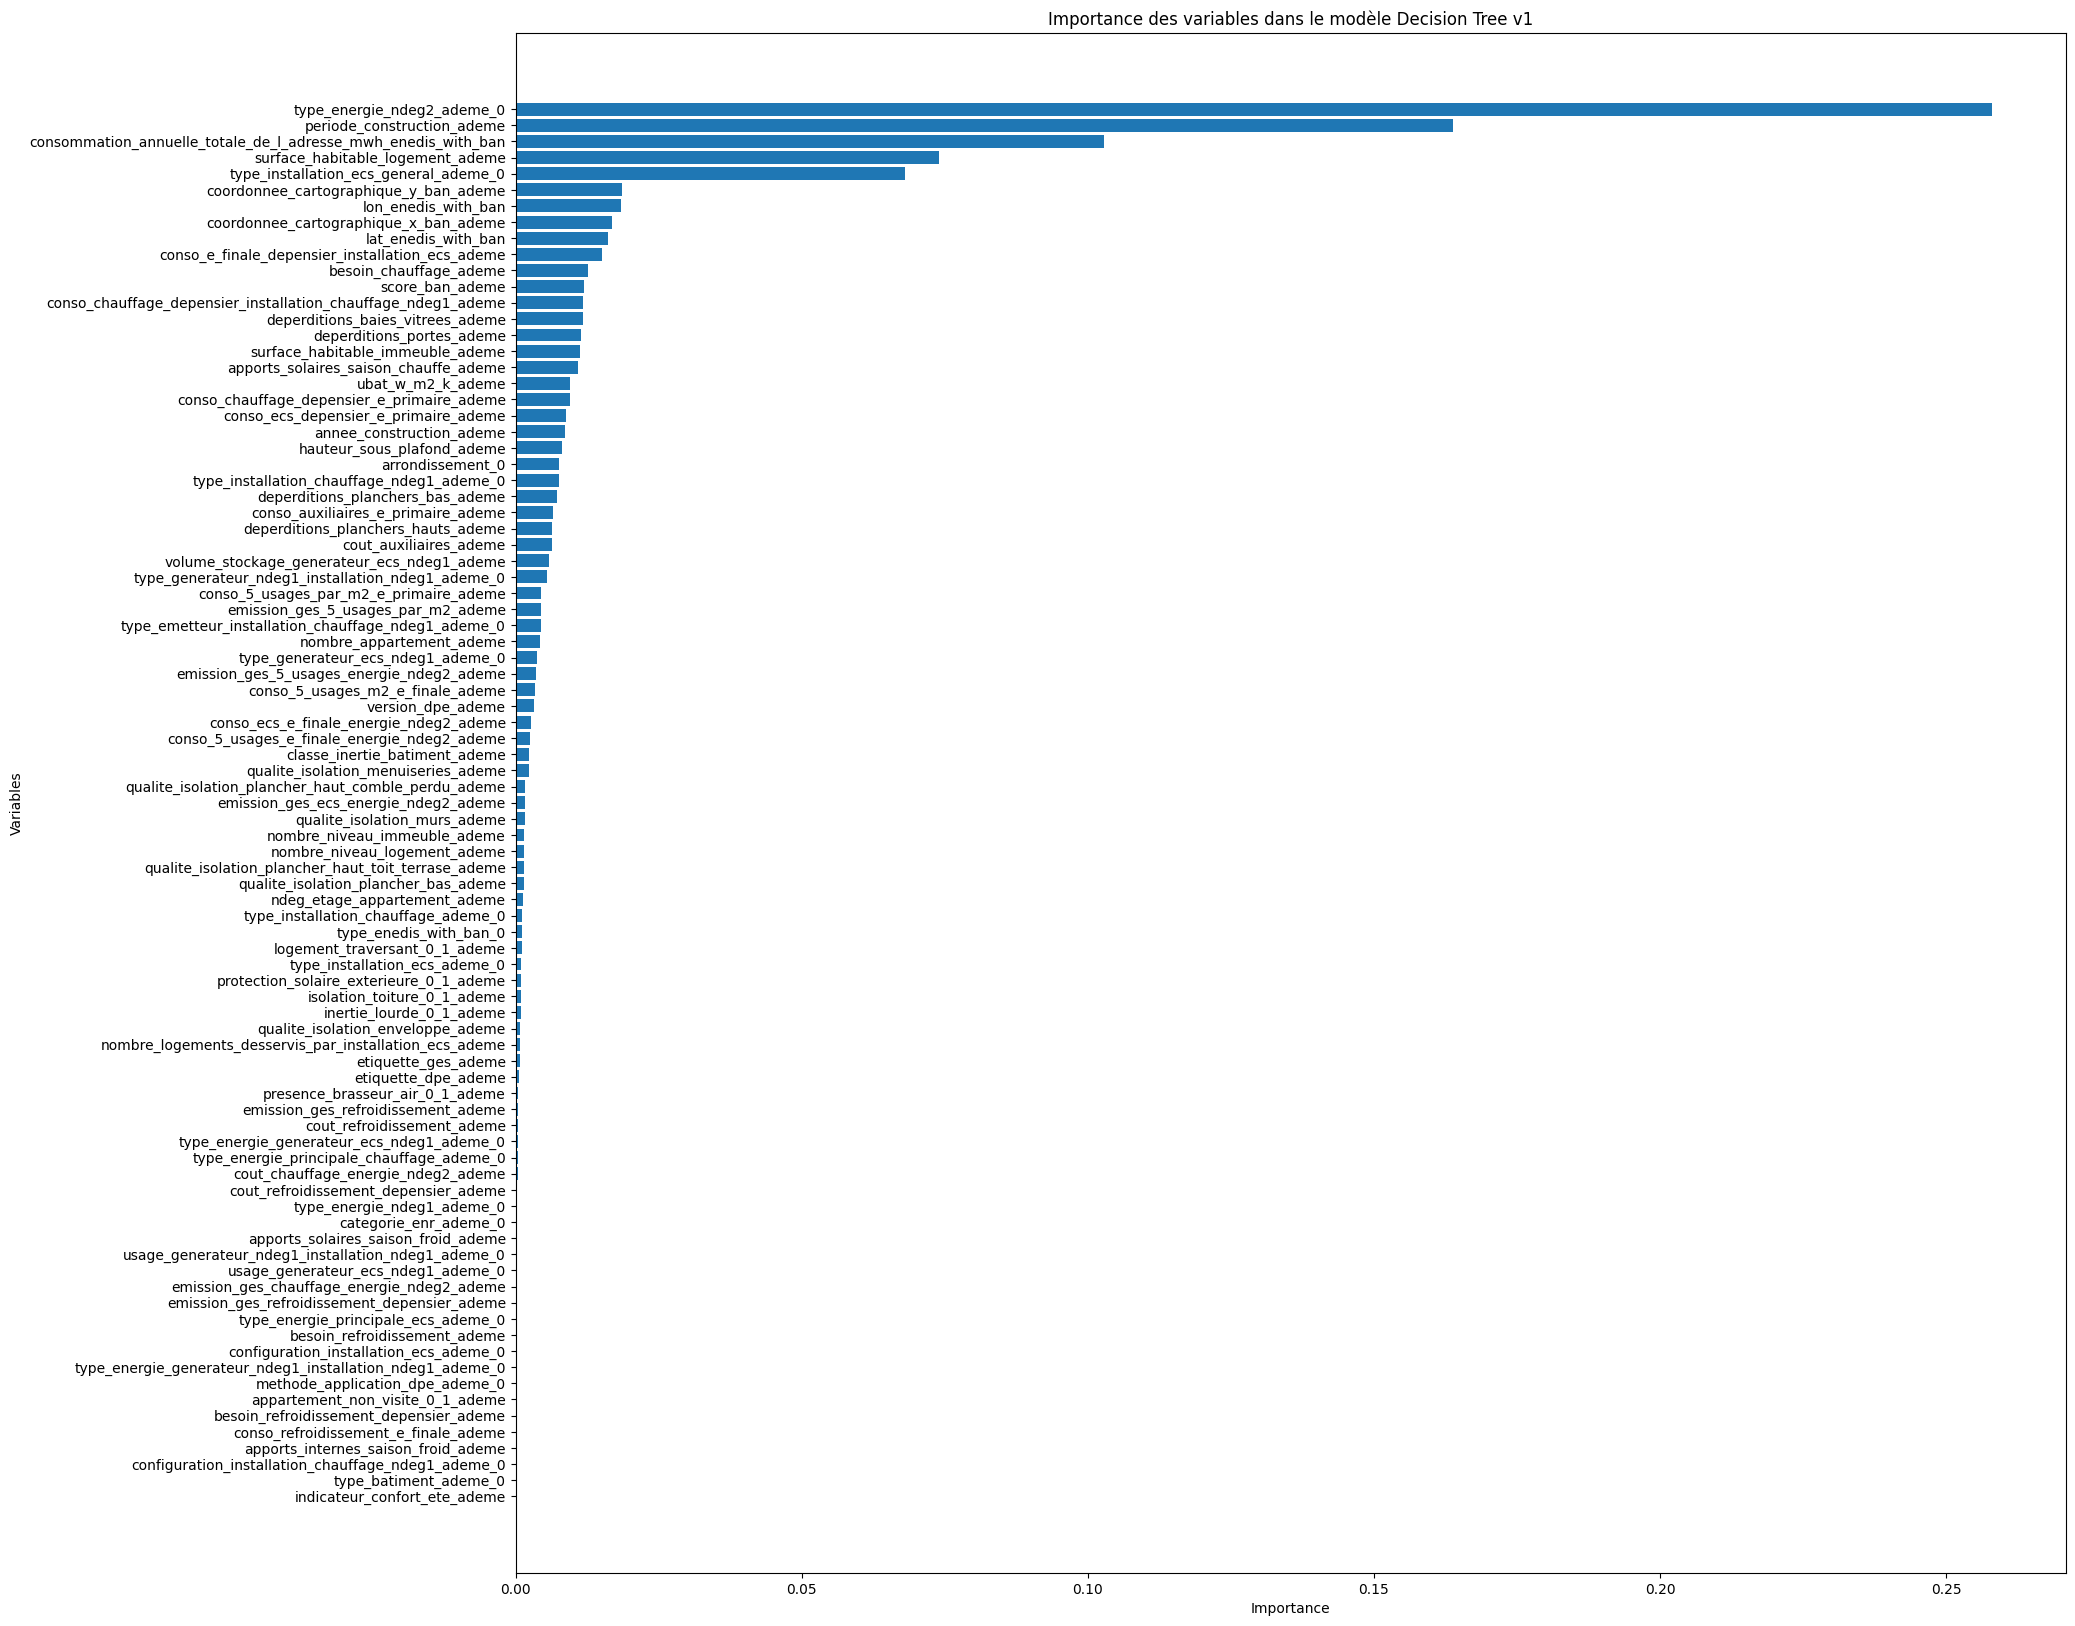

In [19]:
# Tri des variables par importance croissante
sorted_idx = np.argsort(DT.feature_importances_)
# Importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns[sorted_idx], DT.feature_importances_[sorted_idx])
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Importance des variables dans le modèle Decision Tree v1')
plt.savefig('../ressources/img/importance_variables_DT1_sorted_carla.png')
#plt.show()


In [14]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_dt, '../ressources/models_fitted/decision_tree_model_v1_carla.pkl')


['../ressources/models_fitted/decision_tree_model_v1_carla.pkl']

Version 2 avec les hypers paramtres

In [21]:
# apprentissage du modèle avec des hyperparamètres
DT2 = DecisionTreeRegressor( random_state=25, max_depth=15)

mdl_dt2 = DT2.fit(x_train, y_train)
y_pred2 = mdl_dt2.predict(x_test)
mse2 = mean_squared_error(y_test, y_pred2)
mape2 = mean_absolute_percentage_error(y_test, y_pred2)
mse2, mape2, r2_score(y_test, y_pred2), root_mean_squared_error(y_test, y_pred2)
# avant : (622664.0017882059, 0.16527461646755634, 0.623219190956817, 789.0906169688028)
# avec 10 :(506659.12307232607, 0.20115799945796897, 0.6934150139528484, 711.799917864793)
# avec 20 :(509797.43845185597, 0.16286893446552722, 0.6915159849350538, 714.0010073185163)
# avec 15 : (474069.40312568436, 0.1743571106396366, 0.7131354105274413, 688.5269806809929)

(474069.40312568436, 0.1743571106396366, 0.7131354105274413, 688.5269806809929)

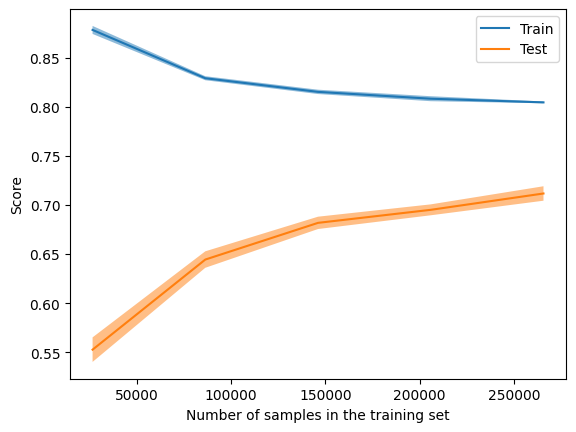

In [16]:
train_sizes2, train_scores2, test_scores2 = learning_curve(DT2, x_train, y_train, cv=10)

display = LearningCurveDisplay(train_sizes=train_sizes2,train_scores=train_scores2, test_scores=test_scores2, score_name="Score")

display.plot()
plt.savefig('../ressources/img/learning_curve_DT2_carla.png')
plt.show()


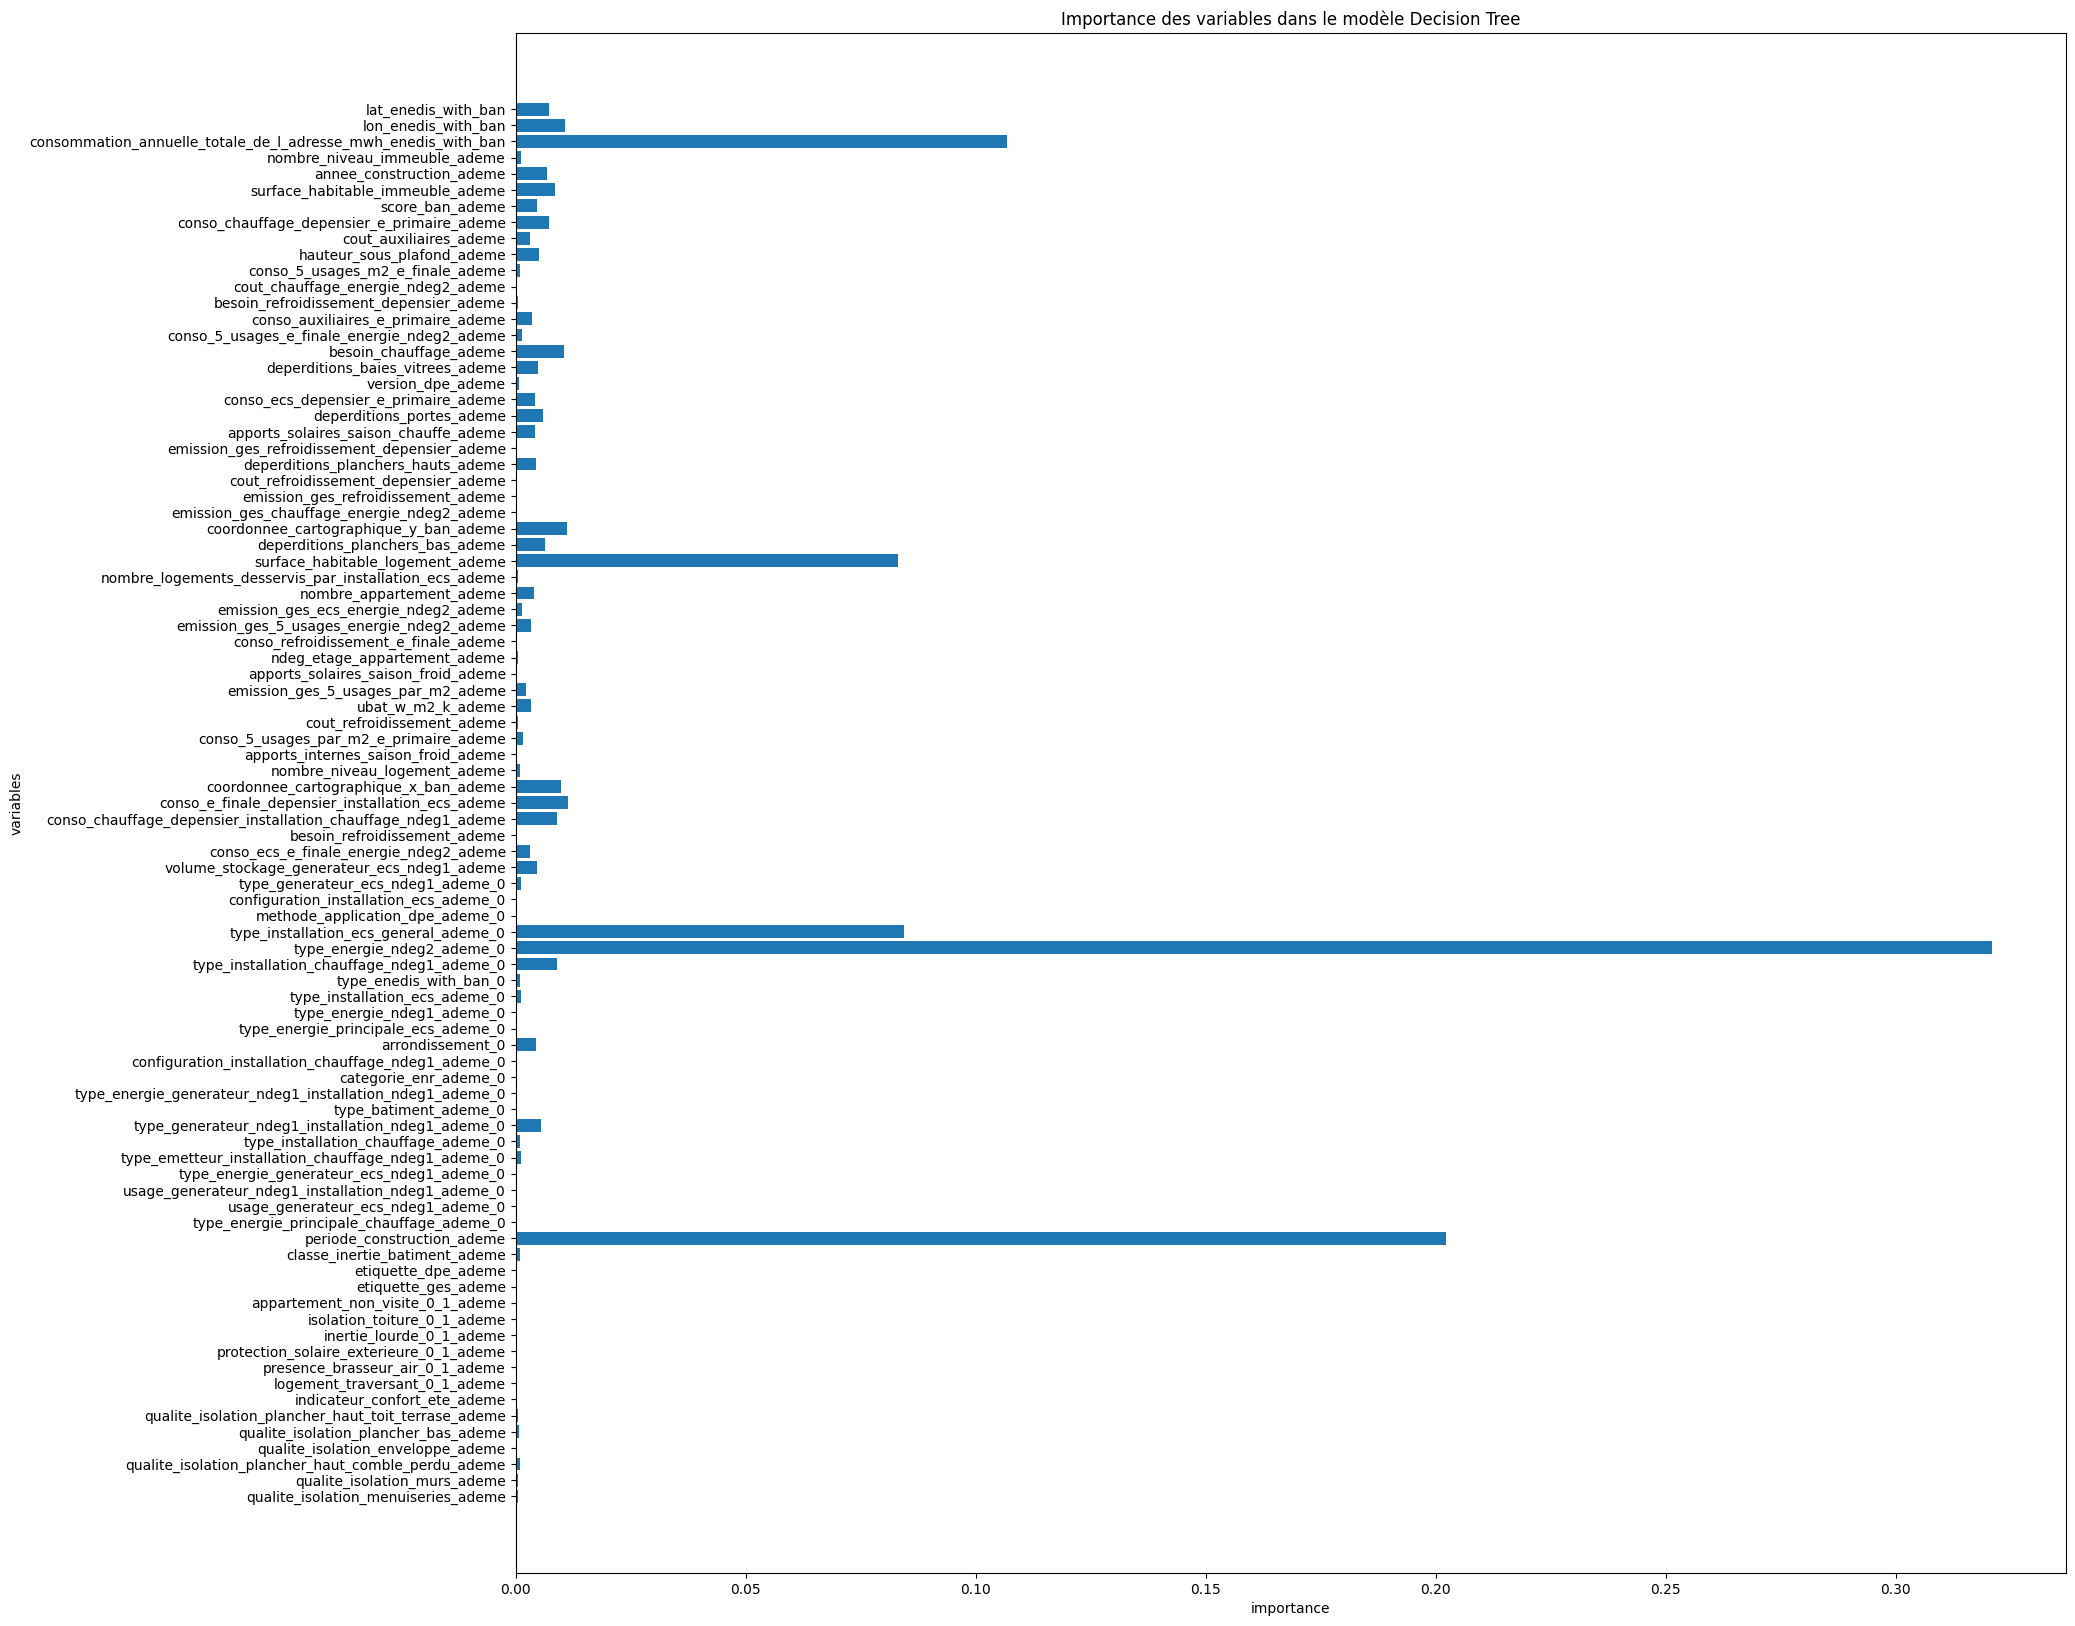

In [17]:
DT2.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, DT2.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree')
plt.savefig('../ressources/img/importance_variables_DT2_carla.png')
plt.show()


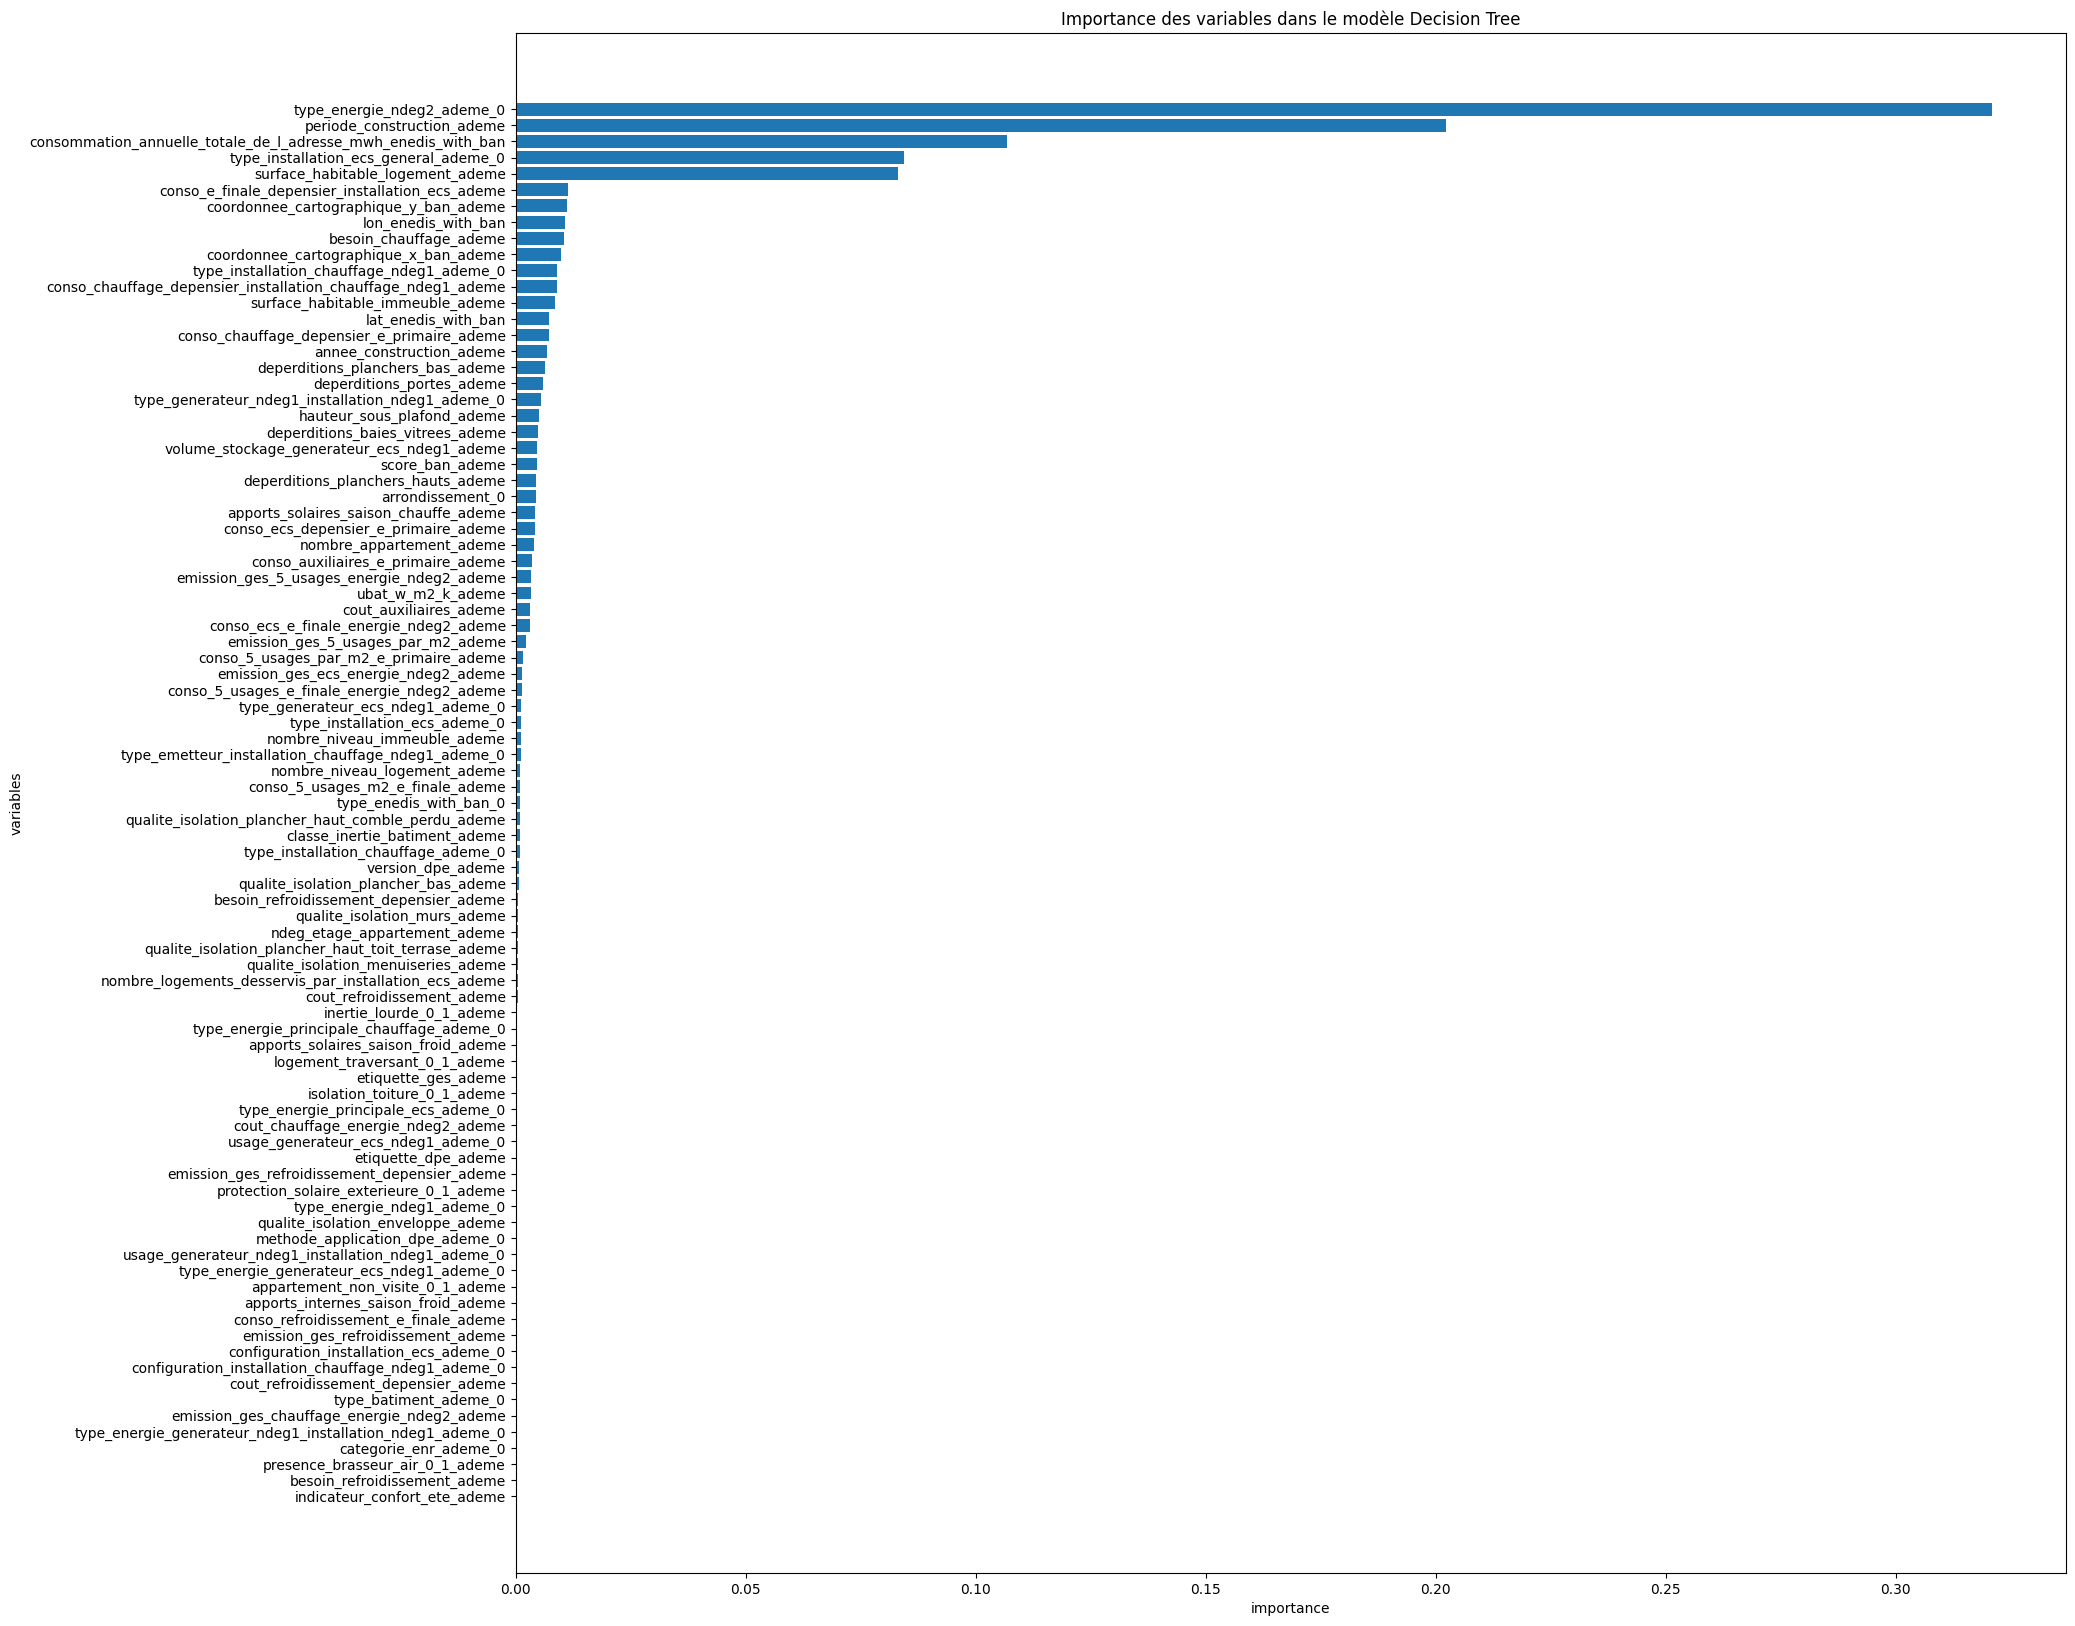

In [22]:
# Tri des variables par importance croissante
sorted_idx2 = np.argsort(DT2.feature_importances_)
# Importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns[sorted_idx2], DT2.feature_importances_[sorted_idx2])
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree')
plt.savefig('../ressources/img/importance_variables_DT2_sorted_carla.png')

In [18]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_dt2, '../ressources/models_fitted/decision_tree_model_v2_carla.pkl')

['../ressources/models_fitted/decision_tree_model_v2_carla.pkl']

# 2.Random forest

In [23]:
# apprentissage du modèle 
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(n_estimators=20, max_features=10)

mdl_rf = RF.fit(x_train, y_train)
y_pred3 = mdl_rf.predict(x_test)
mse3 = mean_squared_error(y_test, y_pred3)
mape3 = mean_absolute_percentage_error(y_test, y_pred3)
mse3, mape3, r2_score(y_test, y_pred3), root_mean_squared_error(y_test, y_pred3)

(348309.5406361339, 0.15068532003813132, 0.7892340810751077, 590.1775500949981)

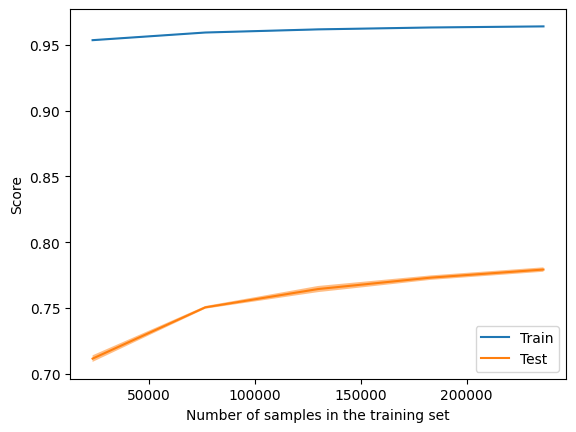

In [10]:
# courbe d'apprentissage 

train_sizes3, train_scores3, test_scores3 = learning_curve(
RF, x_train, y_train, cv=5, scoring='r2')

display = LearningCurveDisplay(train_sizes=train_sizes3,
train_scores=train_scores3, test_scores=test_scores3, score_name="Score")

display.plot()
plt.savefig('../ressources/img/learning_curve_RF1_carla.png')
# plt.show()

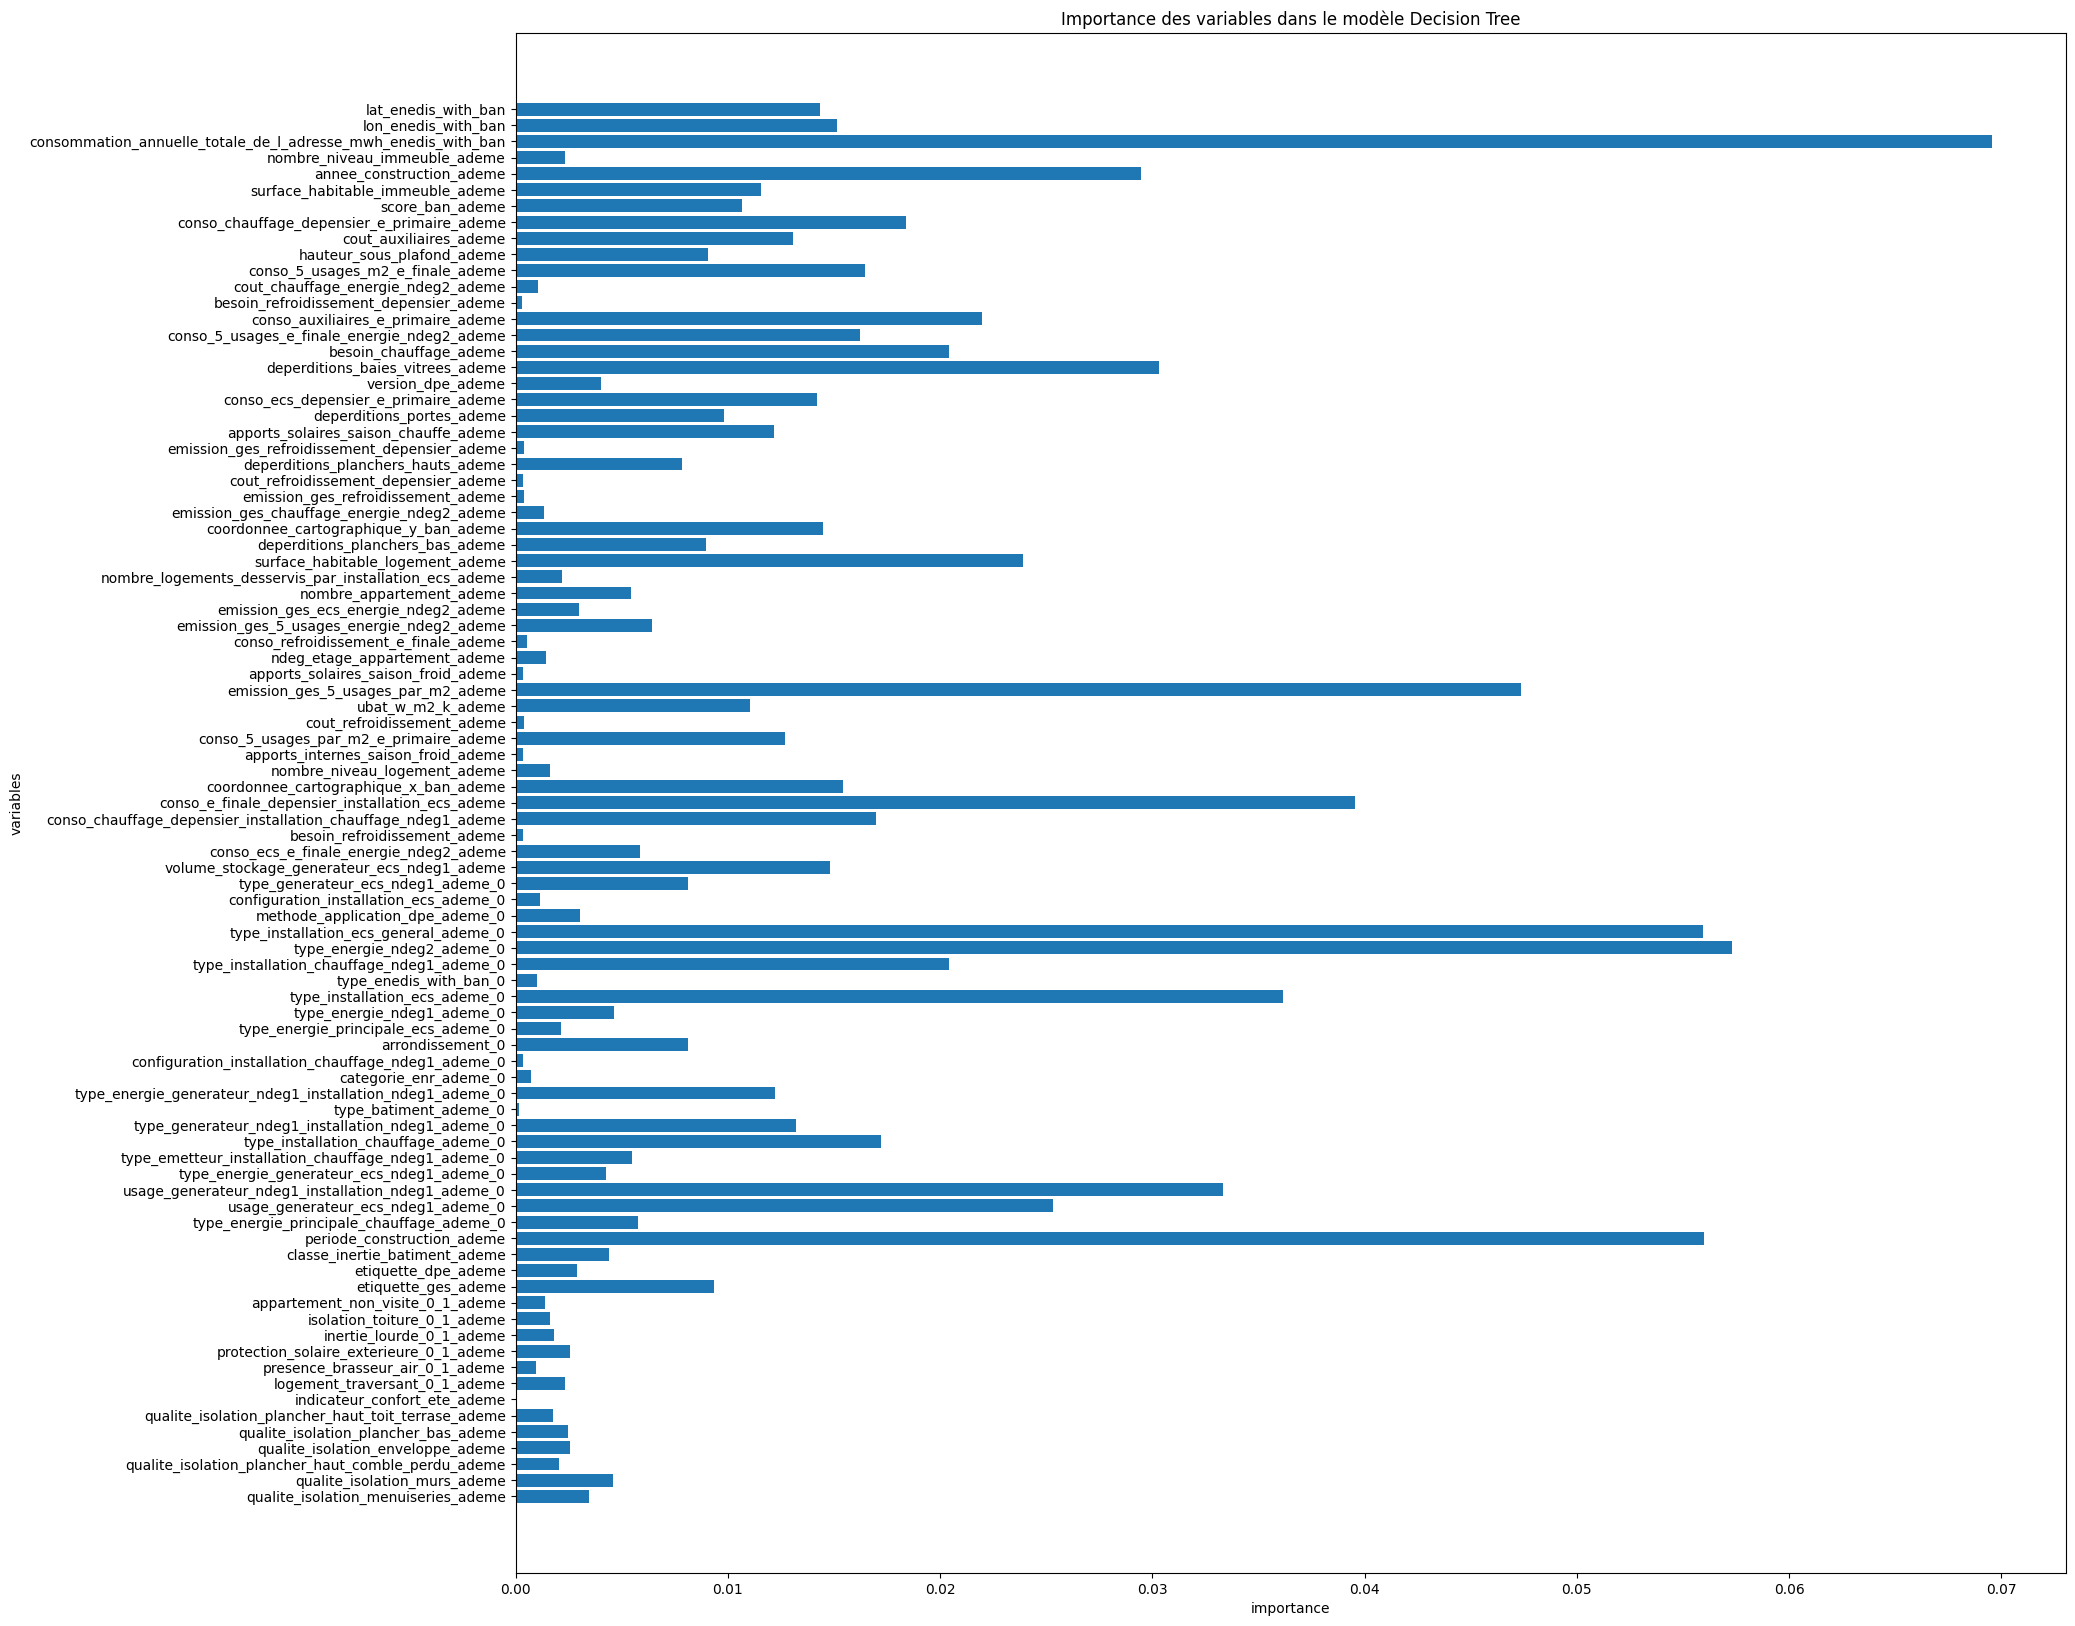

In [11]:
RF.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, RF.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree')
plt.savefig('../ressources/img/importance_variables_RF1_carla.png')
plt.show()


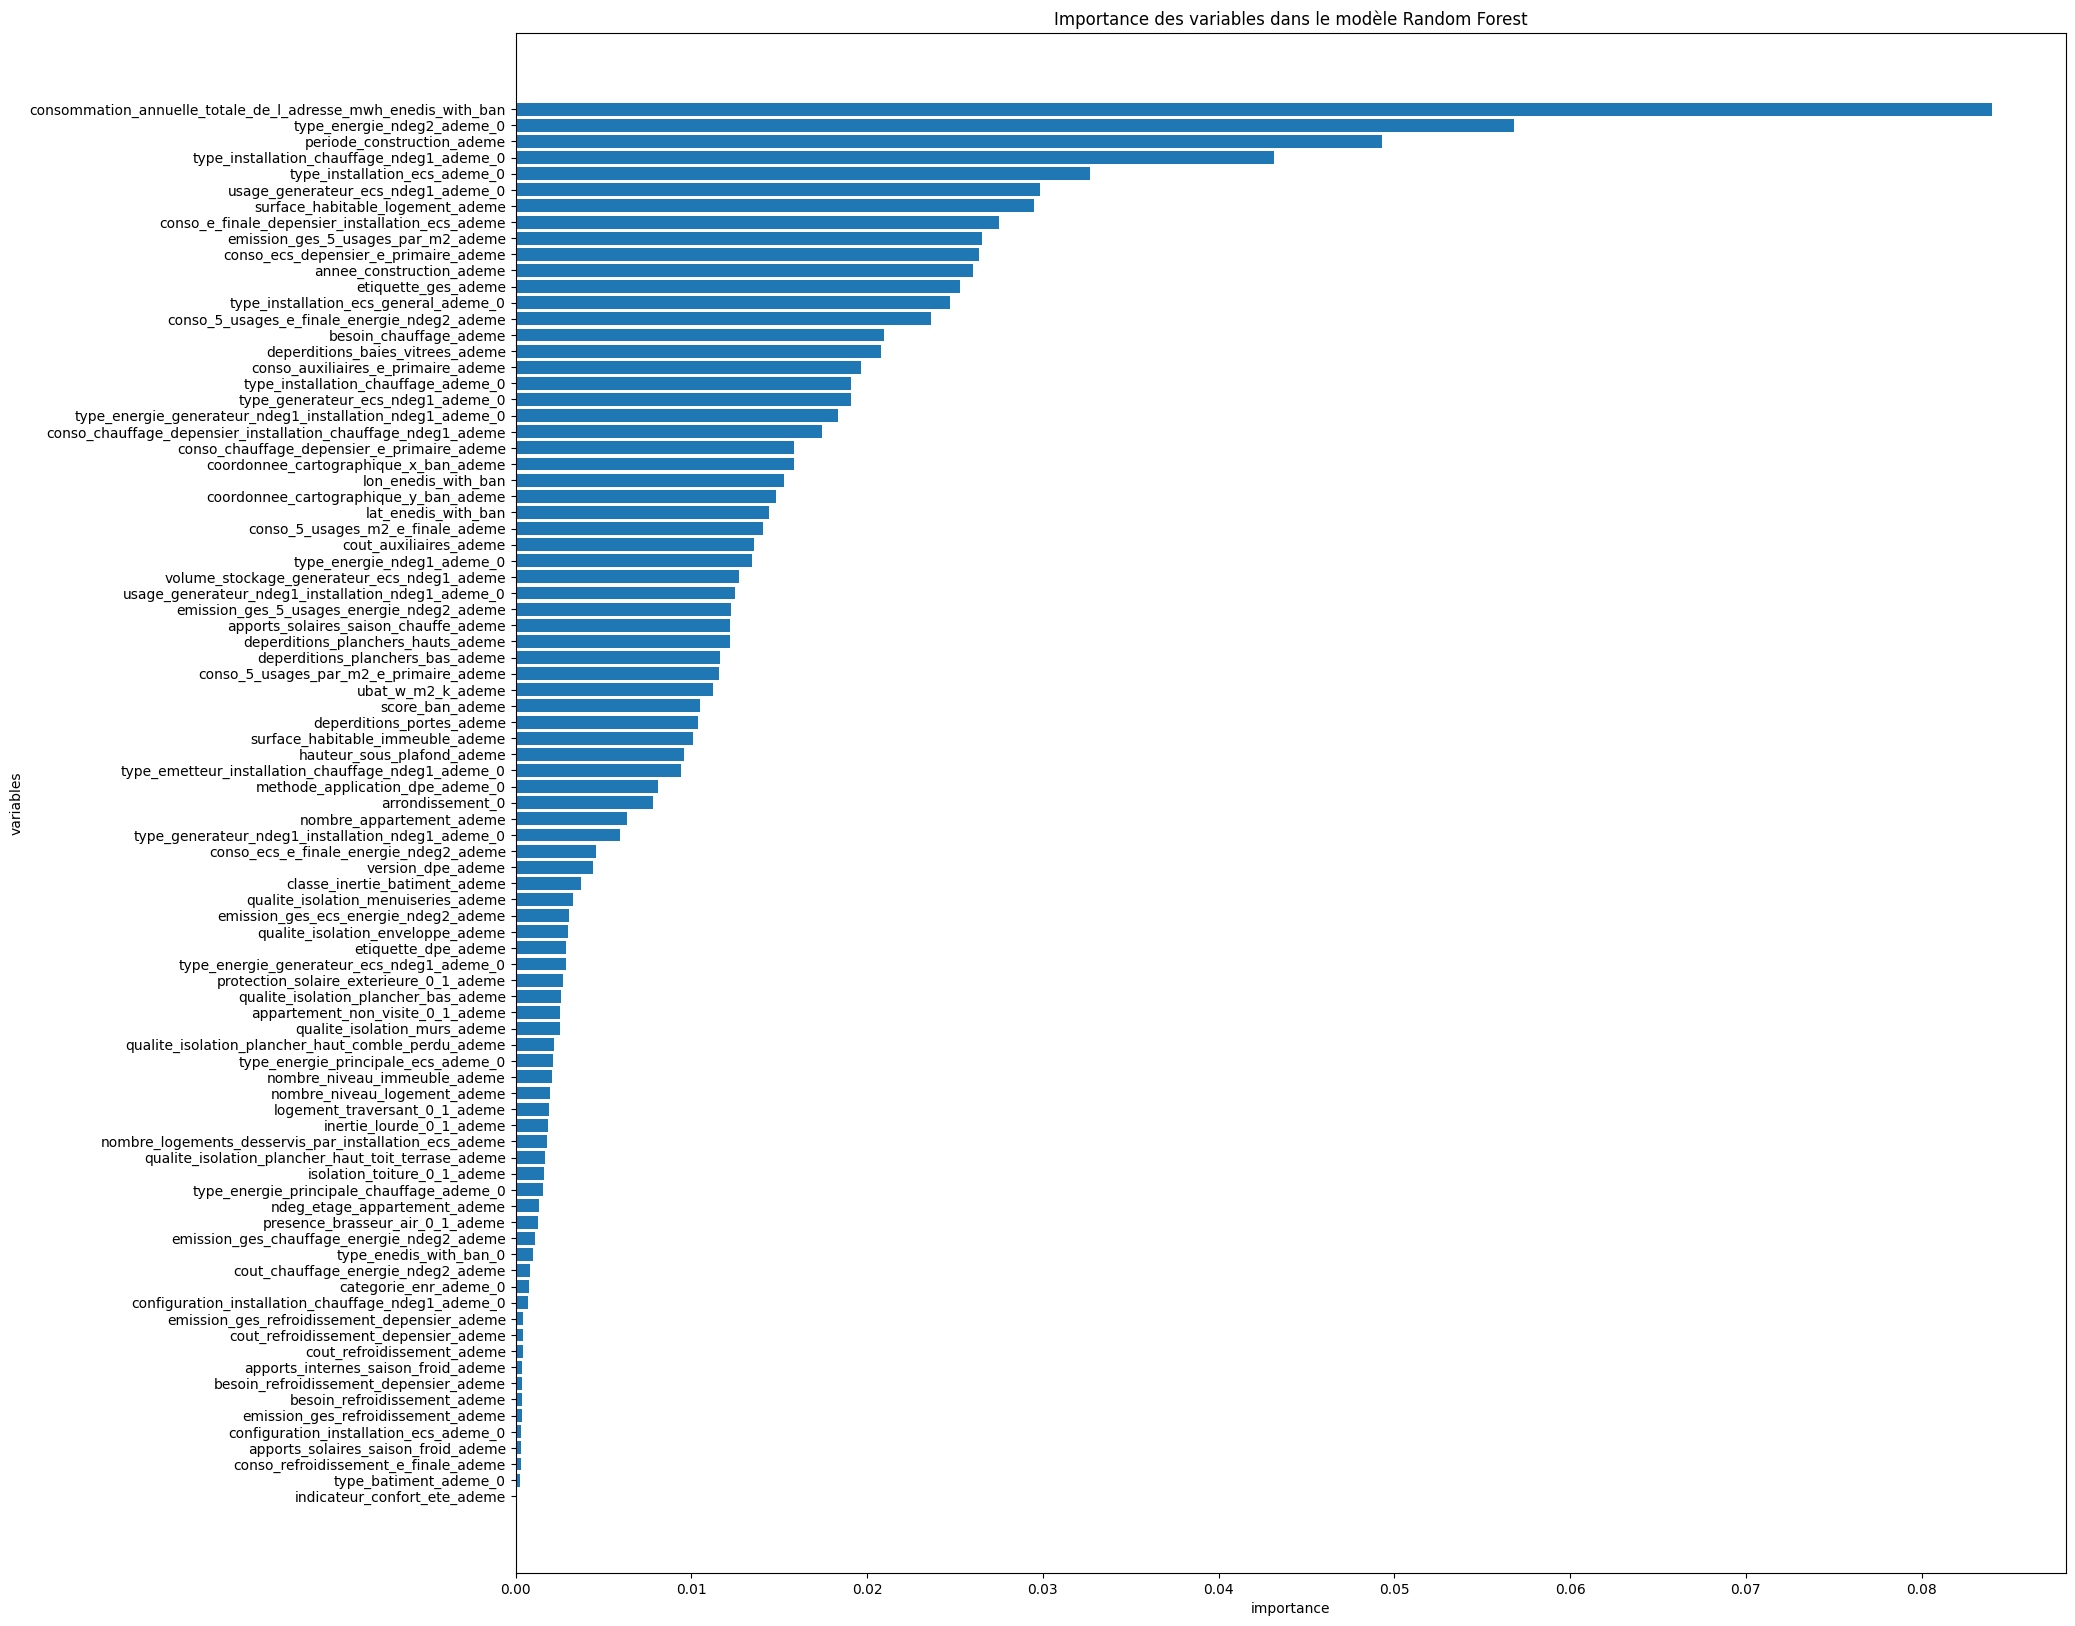

In [31]:
# Tri des variables par importance croissante
sorted_idx3 = np.argsort(RF.feature_importances_)
# Importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns[sorted_idx3], RF.feature_importances_[sorted_idx3])
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Random Forest')
plt.savefig('../ressources/img/importance_variables_RF1_sorted_carla.png')

In [12]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_rf, '../ressources/models_fitted/random_forest_model_v1_carla.pkl')

['../ressources/models_fitted/random_forest_model_v1_carla.pkl']

# Results

In [30]:
print(f'les resultats des différents modèles sont :\n'
      f'DT1 : {round(r2_score(y_test, y_pred),2)} \n'
      f'DT2 : {round(r2_score(y_test, y_pred2),2)} \n'
      f'RF1 : {round(r2_score(y_test, y_pred3),2)} \n'
      f'Il apparait donc que le meilleur modèle est le Random Forest')

les resultats des différents modèles sont :
DT1 : 0.61 
DT2 : 0.71 
RF1 : 0.79 
Il apparait donc que le meilleur modèle est le Random Forest


In [ ]:
print(f'Interprétation : \n'
      f'le Random Forest s\'appuie sur les variables suivantes :\n'
      f'')

# LightGBM

In [11]:
! pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 753.5 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# LightGBM
import lightgbm as lgb
from lightgbm import LGBMClassifier


lgbm = LGBMClassifier(n_estimators=5, max_depth=5)
mdl_lgbm = lgbm.fit(x_train, y_train)
y_pred4 = mdl_lgbm.predict(x_test)
mse4 = mean_squared_error(y_test, y_pred4)
mape4 = mean_absolute_percentage_error(y_test, y_pred4)
mse4, mape4, r2_score(y_test, y_pred4), root_mean_squared_error(y_test, y_pred4)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11086
[LightGBM] [Info] Number of data points in the train set: 295264, number of used features: 86
[LightGBM] [Info] Start training from score -9.762412
[LightGBM] [Info] Start training from score -12.595625
[LightGBM] [Info] Start training from score -12.595625
[LightGBM] [Info] Start training from score -12.595625
[LightGBM] [Info] Start training from score -9.823036
[LightGBM] [Info] Start training from score -10.803866
[LightGBM] [Info] Start training from score -12.595625
[LightGBM] [Info] Start training from score -11.209331
[LightGBM] [Info] Start training from score -11.902478
[LightGBM] [Info] Start training from score -10.803866
[LightGBM] [Info] Start training from score -10.649715
[LightGBM] [Info] Start training from scor

: 

In [ ]:
# courbe d'apprentissage 
from sklearn.model_selection import learning_curve, LearningCurveDisplay
train_sizes4, train_scores4, test_scores4 = learning_curve(
lgbm, x_train, y_train, cv=5, scoring='r2')

display = LearningCurveDisplay(train_sizes=train_sizes4,
train_scores=train_scores4, test_scores=test_scores4, score_name="Score")

display.plot()
plt.savefig('../ressources/img/learning_curve_lgbm1_carla.png')
# plt.show()

In [ ]:
# barre plot de corrélation des variables avec la target
# corrélation des variables avec le DPE
# faire one hot sur les variables qualitatives et faire une PCA sur ce variables pour ne garder qu'une partie